# <b><h1 style="font-size: 3rem;">Blood Donation Prediction Using Machine Learning</b></h1>

## <b>Project Introduction</b>

<i><b><span style="font-size: large;">Problem Statement</i></span>
- ##### Predict whether a blood donor will donate blood in March 2007 using historical donation behavior.

<i><b><span style="font-size: large;">Objective</i></span>
- ##### Develop and compare multiple machine learning models and recommend the best production-ready solution.

## Importing Libraries

In [64]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [65]:
#Load Data
df = pd.read_csv("Warm_Up_Predict_Blood_Donations_-_Traning_Data.csv")

## Basic Checks

In [66]:
df.shape

(576, 6)

In [67]:
df.columns

Index(['Unnamed: 0', 'Months since Last Donation', 'Number of Donations',
       'Total Volume Donated (c.c.)', 'Months since First Donation',
       'Made Donation in March 2007'],
      dtype='object')

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [69]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


In [70]:
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


## Data Cleaning

In [71]:
df.isnull().sum() #checking null value

Unnamed: 0                     0
Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

In [72]:
df.dtypes

Unnamed: 0                     int64
Months since Last Donation     int64
Number of Donations            int64
Total Volume Donated (c.c.)    int64
Months since First Donation    int64
Made Donation in March 2007    int64
dtype: object

In [73]:
#dropping column'Unnamed:0' as it had no impact on target variable
df = df.drop("Unnamed: 0", axis=1)

In [74]:
df = df.drop_duplicates() #removing duplicate data

In [75]:
df

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
566,23,1,250,23,1
572,16,3,750,86,0
573,21,2,500,52,0
574,39,1,250,39,0


##### <i>The data had 576 columns of which 153 rows were duplicates. <b><span style="color: blue;">The Dataset was small</span></b> and its <b><span style="color: #008000;">size was further reduced due to duplicate rows</span></b> which can pose a challenge in model training


## EDA

In [76]:
#checking for target balance
df["Made Donation in March 2007"].value_counts()

Made Donation in March 2007
0    305
1    118
Name: count, dtype: int64

In [77]:
df["Made Donation in March 2007"].value_counts(normalize=True) * 100

Made Donation in March 2007
0    72.104019
1    27.895981
Name: proportion, dtype: float64

##### <i>As there is class imbalance, but not very severe, there is no immediate need for SMOTE now. However, evaluation metric selection becomes important, so we <b><span style="color: blue;">don't rely only on accuracy</span></b> but also on <b><span style="color: blue;">Recall, F1-score, and ROC-AUC</span></b>, especially because <b><span style="color:red;">predicting actual donors (1) is more important</span></b> here.</i>

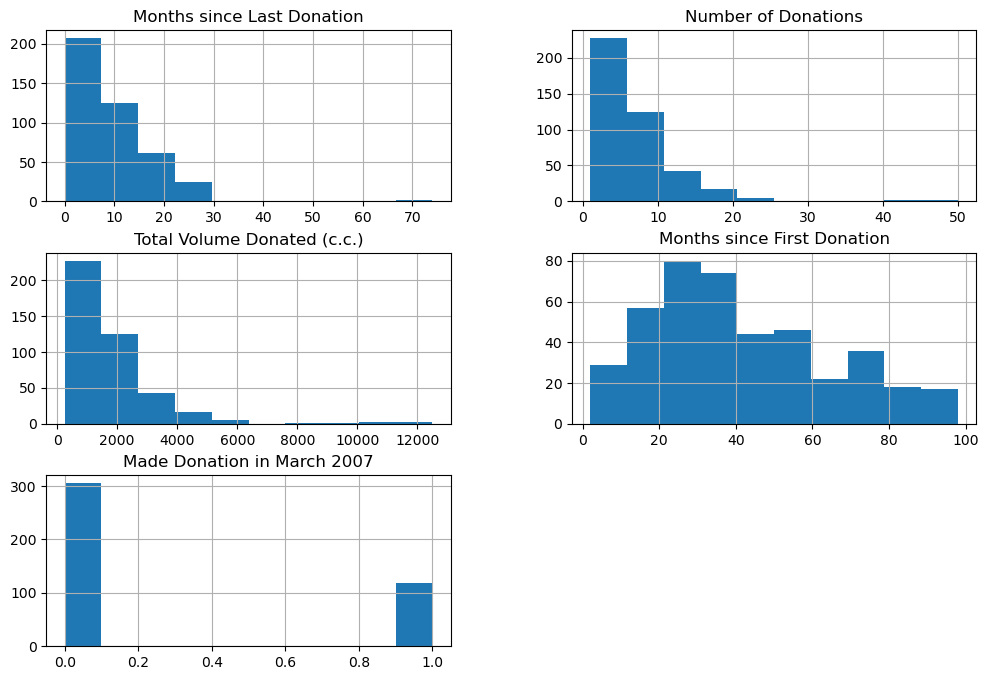

In [78]:
# Histogram
df.hist(figsize=(12,8))
plt.show()

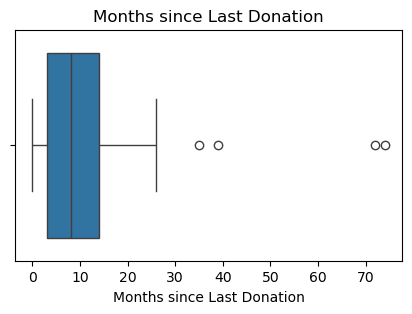

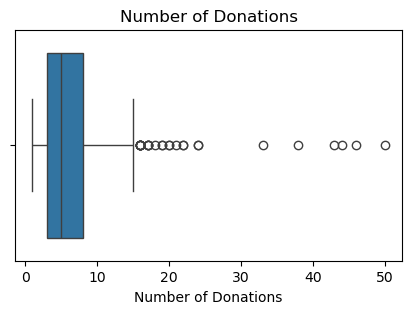

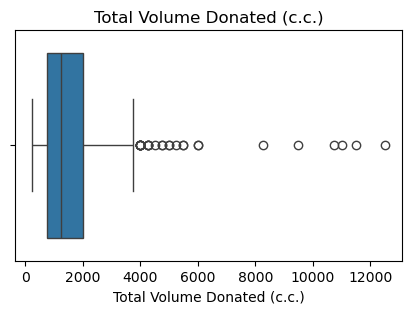

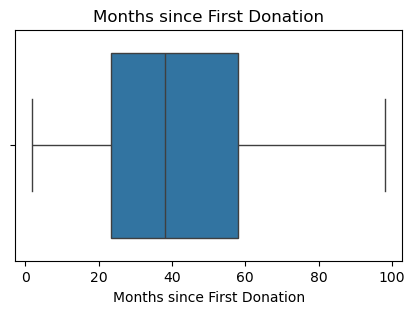

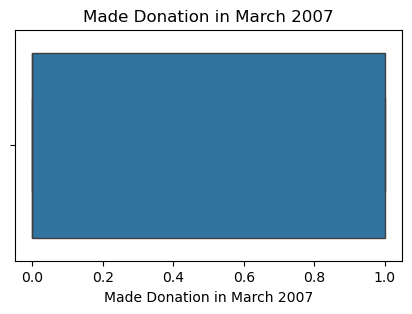

In [79]:
for col in df.columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

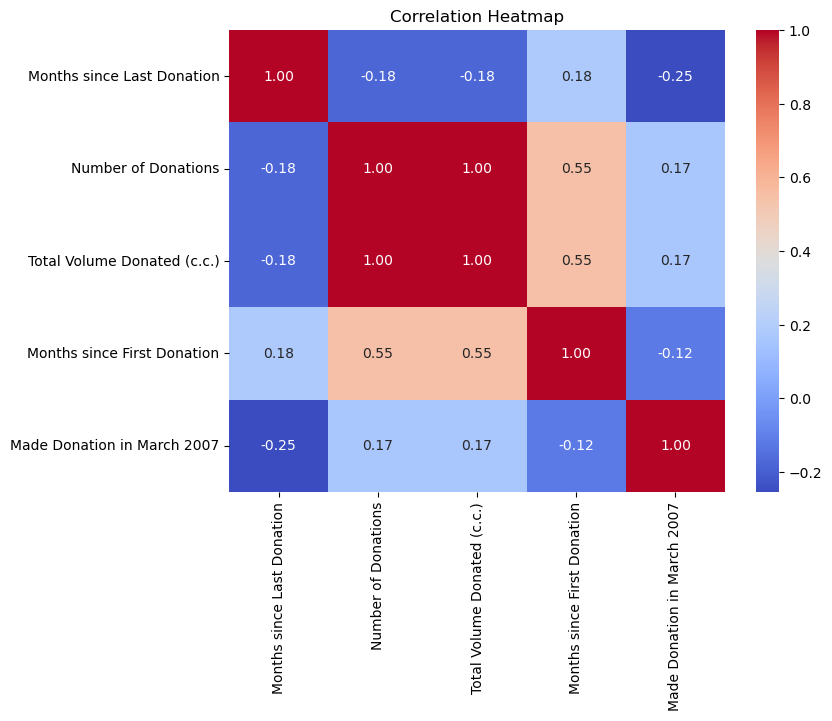

In [80]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

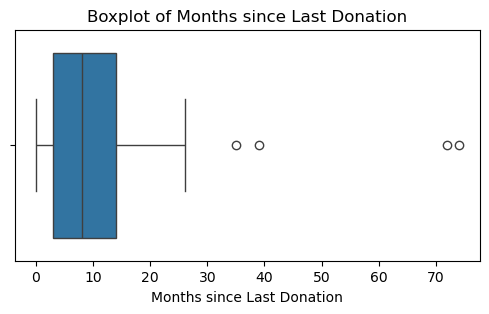

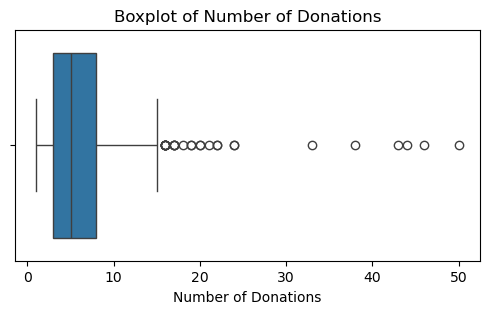

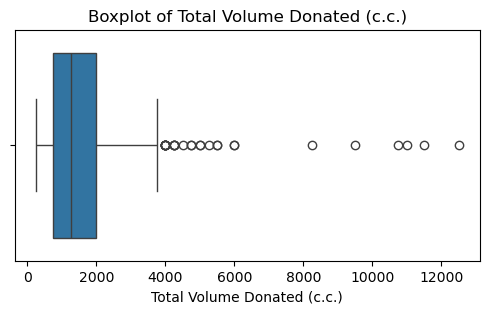

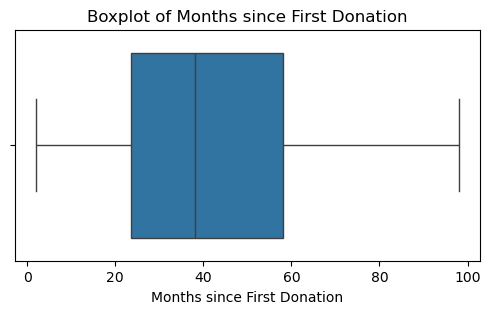

In [81]:
# Checking for outlier
for col in df.columns[:-1]:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

##### The boxplots of <span style="color: blue;"> Number of Donations</span> and <span style="color: blue;">Total Volume Donated</span> look almost identical.
##### This strongly confirms both carry same information and Total Volume Donated is redundant so later during preprocessing we should remove it.

## Data PreProcessing

In [82]:
df_exp = df.copy()
df_exp.head()

,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


### Feature Selection

In [83]:
df_exp = df_exp.drop("Total Volume Donated (c.c.)", axis=1)

### Feature Creation

#### Recent Donor Flag

In [84]:
df_exp["Recent Donor"] = (
    df_exp["Months since Last Donation"] <= 6
).astype(int)

#### Loyal Donor Flag

In [85]:
df_exp["Loyal Donor"] = (
    df_exp["Number of Donations"] >= 10
).astype(int)

#### Long-Term Donor Flag

In [86]:
df_exp["Long-Term Donor"] = (
    df_exp["Months since First Donation"] >= 24
).astype(int)

#### Donation Frequency

In [87]:
df_exp["Donation Frequency"] = (
    df_exp["Number of Donations"] /
    df_exp["Months since First Donation"]
)

#### Donation Momentum

In [88]:
df_exp["Donation Momentum"] = (
    df_exp["Donation Frequency"] /
    (df_exp["Months since Last Donation"] + 1)
)

#### Recency Ratio

In [89]:
df_exp["Recency Ratio"] = (
    df_exp["Months since Last Donation"] /
    df_exp["Months since First Donation"]
)

#### High Engagement Score

In [90]:
df_exp["Engagement Score"] = (
    df_exp["Donation Frequency"] * 100
    - df_exp["Recency Ratio"] * 10
)

<b><span style="color: blue;">Behavior-based features</span></b> were created to better capture <b><span style="color: blue;">donor engagement</span></b> and <b><span style="color: blue;">donation habits</span></b>.

In [91]:
df_exp.columns

Index(['Months since Last Donation', 'Number of Donations',
       'Months since First Donation', 'Made Donation in March 2007',
       'Recent Donor', 'Loyal Donor', 'Long-Term Donor', 'Donation Frequency',
       'Donation Momentum', 'Recency Ratio', 'Engagement Score'],
      dtype='object')

In [92]:
df_exp

,Months since Last Donation,Number of Donations,Months since First Donation,Made Donation in March 2007,Recent Donor,Loyal Donor,Long-Term Donor,Donation Frequency,Donation Momentum,Recency Ratio,Engagement Score
0,2,50,98,1,1,1,1,0.510204,0.170068,0.020408,50.816327
1,0,13,28,1,1,1,1,0.464286,0.464286,0.000000,46.428571
2,1,16,35,1,1,1,1,0.457143,0.228571,0.028571,45.428571
3,2,20,45,1,1,1,1,0.444444,0.148148,0.044444,44.000000
4,1,24,77,0,1,1,1,0.311688,0.155844,0.012987,31.038961
...,...,...,...,...,...,...,...,...,...,...,...
566,23,1,23,1,0,0,0,0.043478,0.001812,1.000000,-5.652174
572,16,3,86,0,0,0,1,0.034884,0.002052,0.186047,1.627907
573,21,2,52,0,0,0,1,0.038462,0.001748,0.403846,-0.192308
574,39,1,39,0,0,0,1,0.025641,0.000641,1.000000,-7.435897


### EDA on New Features

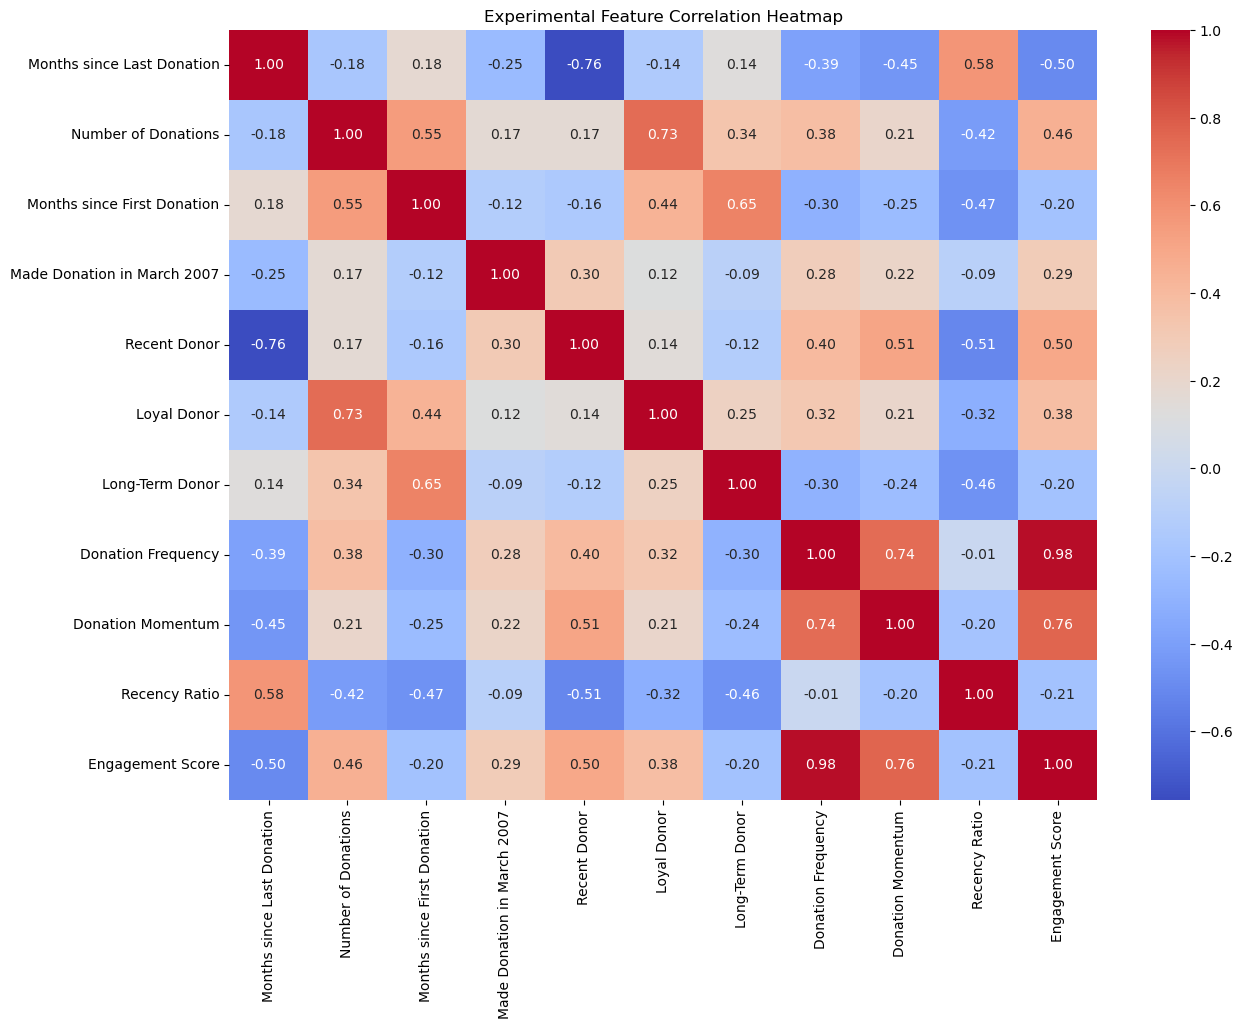

In [93]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df_exp.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Experimental Feature Correlation Heatmap")

plt.show()

Here, after creating new behavioral features, the correlation with the target variable improved noticeably. Features like **Recent Donor**, **Donation Frequency** and **Engagement Score** showed stronger positive relationships with repeat donation behavior. This suggests that recent activity and donation consistency are more important indicators than just total donation history.

The feature **Donation Momentum** also showed a useful relationship with the target, indicating that combining recency and frequency creates a stronger behavioral signal. 

On the other hand, features such as **Long-Term Donor** and **Loyal Donor** had weaker correlations, which suggests that being an old or frequent donor alone does not guarantee future donation.

Another important observation was the very high correlation between **Donation Frequency** and **Engagement Score**, meaning both features carry nearly similar information. One of them can later be removed to reduce redundancy.

Overall, the experimental feature engineering step improved the quality of predictive signals and helped capture donor behavior more effectively.

In [94]:
df_exp_final = df_exp.drop(
    [
        "Months since First Donation",
        "Long-Term Donor",
        "Loyal Donor",
        "Donation Frequency",
        "Recency Ratio"
    ],
    axis=1
)

In [95]:
df_exp_final.columns

Index(['Months since Last Donation', 'Number of Donations',
       'Made Donation in March 2007', 'Recent Donor', 'Donation Momentum',
       'Engagement Score'],
      dtype='object')

In [96]:
X = df_exp_final.drop(
    "Made Donation in March 2007",
    axis=1
)

y = df_exp_final["Made Donation in March 2007"]

### Train-Test Split

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

## Logistic Regression

### Model Training

In [99]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight='balanced')

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

### Evaluation

In [100]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    f1_score
)

print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
roc_auc_score(y_test, y_pred_lr)

[[39 22]
 [ 7 17]]
              precision    recall  f1-score   support

           0       0.85      0.64      0.73        61
           1       0.44      0.71      0.54        24

    accuracy                           0.66        85
   macro avg       0.64      0.67      0.63        85
weighted avg       0.73      0.66      0.68        85



np.float64(0.6738387978142077)

## Random Forest

### Model Training

In [101]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

### Evaluation

In [102]:
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
roc_auc_score(y_test, y_pred_rf)

[[48 13]
 [17  7]]
              precision    recall  f1-score   support

           0       0.74      0.79      0.76        61
           1       0.35      0.29      0.32        24

    accuracy                           0.65        85
   macro avg       0.54      0.54      0.54        85
weighted avg       0.63      0.65      0.64        85



np.float64(0.539275956284153)

## SVM

### Model training

In [103]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)


svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

### Evaluation

In [104]:
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
roc_auc_score(y_test, y_pred_svm)

[[43 18]
 [ 8 16]]
              precision    recall  f1-score   support

           0       0.84      0.70      0.77        61
           1       0.47      0.67      0.55        24

    accuracy                           0.69        85
   macro avg       0.66      0.69      0.66        85
weighted avg       0.74      0.69      0.71        85



np.float64(0.6857923497267759)

### Optimizing

#### Stratified 5-Fold Cross Validation
Maintains class distribution in both training and testing datasets.

In [105]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_model = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42
)


cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='roc_auc'
)

In [106]:
print(cv_scores)
cv_scores.mean()

[0.71535983 0.78088077 0.67669173 0.72807018 0.5430839 ]


np.float64(0.6888172812984843)

#### GridSearchCV + Stratified 5-Fold Cross Validation + SVM
GridSearchCV is used to find best hyper-parameter values

In [107]:
from sklearn.model_selection import GridSearchCV

In [108]:
# PARAMETER GRID
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}


# GRID SEARCH
grid = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=skf,
    scoring='precision',
    verbose=2,
    refit=True
)


# TRAINING
grid.fit(X_train_scaled, y_train)


# BEST PARAMETERS
print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation ROC-AUC:")
print(grid.best_score_)


# BEST MODEL
best_svm = grid.best_estimator_


# PREDICTIONS
y_pred_best_svm = best_svm.predict(X_test_scaled)


# EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_svm))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_best_svm))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01

## SMOTE
<b>Problem Identification</b> - Target distribution was imbalanced.

In [109]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [110]:
#checking counts of classes

print(y_train.value_counts())
print(y_train_smote.value_counts())

Made Donation in March 2007
0    244
1     94
Name: count, dtype: int64
Made Donation in March 2007
1    244
0    244
Name: count, dtype: int64


### SMOTE+GridSearchCV + Stratified 5-Fold Cross Validation + SVM optimization 

In [111]:
grid = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=skf,
    scoring='precision',
    verbose=2,
    refit=True
)

grid.fit(
    X_train_smote,
    y_train_smote
)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(grid.best_score_)

best_svm_smote = grid.best_estimator_

y_pred_smote = best_svm_smote.predict(
    X_test_scaled
)

# EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_smote))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01

### Linear regression+ SMOTE + GridSearchCV + Stratified 5-Fold CV

In [112]:
# LOGISTIC REGRESSION PARAM GRID
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}



lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    lr_param_grid,
    cv=skf,
    scoring='precision',
    verbose=2,
    refit=True
)

lr_grid.fit(
    X_train_smote,
    y_train_smote
)

# BEST PARAMETERS
print("\nBest Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross Validation Score:")
print(lr_grid.best_score_)

best_lr_smote = lr_grid.best_estimator_

# PREDICTIONS
y_pred_lr_smote = best_lr_smote.predict(
    X_test_scaled
)

# EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_smote))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_lr_smote))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...........................C=0.01, solver=liblinear; total time=   0.0s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.0s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.0s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.0s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.0s
[CV] END ...............................C=0.01, solver=lbfgs; total time=   0.0s
[CV] END ............................C=0.1, solver=liblinear; total time=   0.0s
[CV] END ............................C=0.1, solv

<b>SMOTE</b> was explored because it is a standard approach for handling class imbalance. However, synthetic sampling <b>did not improve</b> performance on this dataset.

## XGBoost

In [113]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)


# TRAIN
xgb_model.fit(
    X_train,
    y_train
)

# PREDICT
y_pred_xgb = xgb_model.predict(
    X_test
)

# EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_xgb))


Confusion Matrix:
[[45 16]
 [18  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.74      0.73        61
           1       0.27      0.25      0.26        24

    accuracy                           0.60        85
   macro avg       0.49      0.49      0.49        85
weighted avg       0.59      0.60      0.59        85


ROC-AUC Score:
0.49385245901639335


### OPTIMIZATION

In [114]:
xgb_model_opt = XGBClassifier(
    scale_pos_weight=2.6,
    random_state=42,
    eval_metric='logloss'
)

#Train
xgb_model_opt.fit(X_train, y_train)

#Predict
y_pred_xgb_opt = xgb_model_opt.predict(X_test)

#EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_opt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_opt))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_xgb_opt))


Confusion Matrix:
[[43 18]
 [18  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70        61
           1       0.25      0.25      0.25        24

    accuracy                           0.58        85
   macro avg       0.48      0.48      0.48        85
weighted avg       0.58      0.58      0.58        85


ROC-AUC Score:
0.4774590163934426


#### XG boost + GridSearchCV

In [ ]:
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_param_grid,
    cv=skf,
    scoring='precision',
    verbose=2,
    refit=True
)

xgb_grid.fit(X_train, y_train)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

In [116]:
best_xgb = xgb_grid.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_xgb))


Confusion Matrix:
[[58  3]
 [15  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.95      0.87        61
           1       0.75      0.38      0.50        24

    accuracy                           0.79        85
   macro avg       0.77      0.66      0.68        85
weighted avg       0.78      0.79      0.76        85


ROC-AUC Score:
0.6629098360655737


#### Optimizing Further
<B> try 2</B>

In [117]:
xgb_param_grid_v2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3],
    'learning_rate': [0.01, 0.05],
    'scale_pos_weight': [2, 2.5, 3]
}

xgb_grid_v2 = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_param_grid_v2,
    cv=skf,
    scoring='f1',
    verbose=2,
    refit=True
)

xgb_grid_v2.fit(X_train, y_train)

print("Best Parameters:")
print(xgb_grid_v2.best_params_)

print("\nBest Cross Validation Score:")
print(xgb_grid_v2.best_score_)

best_xgb_v2 = xgb_grid_v2.best_estimator_

y_pred_xgb_v2 = best_xgb_v2.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_v2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_v2))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_xgb_v2))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2.5; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2.5; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2.5; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, scale_pos_weight=2.5; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=

## CatBoost

In [ ]:
!pip install catboost

In [119]:
from catboost import CatBoostClassifier
cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0)

# TRAIN
cat_model.fit(
    X_train,
    y_train)

# PREDICT
y_pred_cat = cat_model.predict(
    X_test
)

# EVALUATION
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cat))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_cat))


Confusion Matrix:
[[57  4]
 [14 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86        61
           1       0.71      0.42      0.53        24

    accuracy                           0.79        85
   macro avg       0.76      0.68      0.69        85
weighted avg       0.78      0.79      0.77        85


ROC-AUC Score:
0.6755464480874318


### Optimizing

#### CatBoost + GridSearchCV

In [120]:
cat_param_grid_v2 = {
    'depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200, 300]
}


cat_grid_v2 = GridSearchCV(
    CatBoostClassifier(
        random_state=42,
        verbose=0
    ),
    cat_param_grid_v2,
    cv=skf,
    scoring='precision',
    verbose=2,
    refit=True
)


cat_grid_v2.fit(X_train, y_train)

print("Best Parameters:")
print(cat_grid_v2.best_params_)

print("\nBest Cross Validation Score:")
print(cat_grid_v2.best_score_)


best_cat_v2 = cat_grid_v2.best_estimator_

y_pred_cat_v2 = best_cat_v2.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_cat_v2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cat_v2))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_pred_cat_v2))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END ........depth=2, iterations=100, learning_rate=0.01; total time=   0.6s
[CV] END ........depth=2, iterations=100, learning_rate=0.01; total time=   0.4s
[CV] END ........depth=2, iterations=100, learning_rate=0.01; total time=   0.3s
[CV] END ........depth=2, iterations=100, learning_rate=0.01; total time=   0.3s
[CV] END ........depth=2, iterations=100, learning_rate=0.01; total time=   0.3s
[CV] END ........depth=2, iterations=100, learning_rate=0.05; total time=   0.3s
[CV] END ........depth=2, iterations=100, learning_rate=0.05; total time=   0.3s
[CV] END ........depth=2, iterations=100, learning_rate=0.05; total time=   0.3s
[CV] END ........depth=2, iterations=100, learning_rate=0.05; total time=   0.3s
[CV] END ........depth=2, iterations=100, learning_rate=0.05; total time=   0.3s
[CV] END .........depth=2, iterations=100, learning_rate=0.1; total time=   0.3s
[CV] END .........depth=2, iterations=100, lear

##### SVM and XGBoost exhibited best results and also different strengths. Combining them may improve overall performance.

## Soft Voting Ensemble(Best SVM + Best XGBoost)

In [121]:
# SVM SCORES

svm_score = best_svm.decision_function(
    X_test_scaled)

# XGBOOST PROBABILITIES


xgb_prob = best_xgb_v2.predict_proba(
    X_test
)[:, 1]



# NORMALIZE SVM SCORES

from sklearn.preprocessing import MinMaxScaler

scaler_temp = MinMaxScaler()

svm_prob = scaler_temp.fit_transform(
    svm_score.reshape(-1, 1)
).ravel()



# SOFT VOTING

ensemble_prob_v2 = (
    svm_prob + xgb_prob
) / 2



# PREDICTIONS
y_pred_ensemble_v2 = (
    ensemble_prob_v2 >= 0.5
).astype(int)



# EVALUATION

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ensemble_v2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble_v2))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, ensemble_prob_v2))


Confusion Matrix:
[[50 11]
 [ 9 15]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        61
           1       0.58      0.62      0.60        24

    accuracy                           0.76        85
   macro avg       0.71      0.72      0.72        85
weighted avg       0.77      0.76      0.77        85


ROC-AUC Score:
0.7711748633879781


### Optimizing

In [122]:
thresholds = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65]

for t in thresholds:

    y_pred_temp = (
        ensemble_prob_v2 >= t
    ).astype(int)

    f1 = f1_score(
        y_test,
        y_pred_temp
    )

    print(
        f"Threshold={t:.2f} | F1={f1:.4f}"
    )

Threshold=0.35 | F1=0.5405
Threshold=0.40 | F1=0.5231
Threshold=0.45 | F1=0.5818
Threshold=0.50 | F1=0.6000
Threshold=0.55 | F1=0.5909
Threshold=0.60 | F1=0.5500
Threshold=0.65 | F1=0.1379


#####  Threshold tuning does not show better results and is not needed here.

## Conclusion
#### Key Learnings
* Feature engineering significantly improved model quality.
* Duplicate removal improved data integrity.
* Class imbalance required special handling.
* Accuracy alone is misleading for imbalanced datasets.
* Ensemble learning delivered the strongest performance.

## Final Result
<b><span style="color:green;">Best Model:
Soft Voting Ensemble

<b><span style="color:green;">ROC-AUC:
≈ 0.771

## REPORT

## <b><h1 style="font-size: 3rem;">Blood Donation Prediction Using Machine Learning</b></h1>

### Project Overview

The objective of this project was to predict whether a blood donor would donate blood in March 2007 using historical donation records. The problem was treated as a binary classification task where the target variable indicated whether a donor donated blood during the specified period.

The dataset contained donor behavior information such as donation recency, frequency, total donations, and overall donation history. Since blood banks depend on donor retention and timely identification of potential donors, accurate prediction can help improve donor outreach strategies and resource planning.

---

### Data Understanding and Preprocessing

The project began with a detailed examination of the dataset, including checks for data types, missing values, duplicate records, and target class distribution.

One important observation was the presence of duplicate records within the dataset. These duplicates were removed during the data cleaning stage to improve data quality and reduce bias caused by repeated observations. Although this improved dataset reliability, it further reduced the number of available records, creating an additional challenge for model development.

The dataset also exhibited class imbalance, with significantly more non-donors than donors. This imbalance influenced model performance and required special consideration during experimentation.

---

### Exploratory Data Analysis and Feature Engineering

Exploratory Data Analysis (EDA) was performed to understand donor behavior and identify relationships among variables.

Key observations included:

* Donors who donated recently were more likely to donate again.
* Donation frequency showed a strong relationship with future donations.
* Long donation history alone was not a strong predictor of future behavior.

To improve predictive performance, several new features were engineered from the original dataset. These features were designed to better capture donor engagement and behavioral patterns.

Examples of engineered features included:

* Donation Frequency
* Recency Ratio
* Donation Momentum
* Recent Donor Indicator
* Loyal Donor Indicator
* Long-Term Donor Indicator
* Engagement Score

Feature selection was subsequently performed to remove redundant or weak predictors. Correlation analysis revealed that some engineered variables carried overlapping information, allowing the model to focus on the most informative features.

---

### Model Development and Optimization

Multiple machine learning algorithms were evaluated throughout the project.

The following models were implemented and compared:

* Logistic Regression
* Random Forest
* Support Vector Machine (SVM)
* XGBoost
* CatBoost

To ensure reliable performance estimation, Stratified 5-Fold Cross Validation was applied. This approach maintained class balance across folds and reduced evaluation variance.

GridSearchCV was used to optimize model hyperparameters, particularly for SVM, XGBoost, and CatBoost. Different optimization metrics such as Precision, Recall, F1-Score, and ROC-AUC were explored to understand how model behavior changed under different objectives.

Because the dataset was imbalanced, SMOTE (Synthetic Minority Oversampling Technique) was also tested as a class imbalance handling strategy. While SMOTE is widely used in classification problems, it did not improve performance on this dataset and therefore was not included in the final solution.

---

### Evaluation Metrics

Accuracy was not used as the primary evaluation metric because the dataset contained an imbalanced target distribution. A model could achieve misleadingly high accuracy by favoring the majority class.

Instead, greater emphasis was placed on:

* Precision
* Recall
* F1-Score
* ROC-AUC Score

Among these metrics, ROC-AUC was considered the most important because it evaluates the model's ability to distinguish between donors and non-donors across multiple classification thresholds.

---

### Final Model and Results

After comparing multiple individual models, ensemble learning was explored to combine the strengths of different algorithms.

The best performing solution was a Soft Voting Ensemble consisting of:

* Support Vector Machine (SVM)
* XGBoost

The ensemble combined prediction probabilities from both models and produced more balanced and reliable predictions than either model individually.

Additional experiments involving weight optimization and threshold tuning were performed to further improve ensemble performance.

#### Final Result

**Selected Model:** Soft Voting Ensemble (SVM + XGBoost)

**ROC-AUC Score:** Approximately 0.77

This model demonstrated the strongest overall performance and provided the best balance between donor identification capability and prediction reliability.

---

### Conclusion

This project demonstrated the importance of data preparation, feature engineering, model comparison, and proper evaluation techniques in machine learning. Feature engineering significantly improved predictive performance, while ensemble learning successfully combined the strengths of multiple algorithms.

Despite challenges such as duplicate records, limited dataset size, and class imbalance, the final Soft Voting Ensemble achieved the highest overall performance and is recommended as the production-ready solution for blood donation prediction.

Future improvements may include the use of larger datasets, additional donor attributes, and advanced ensemble methods such as stacking to further enhance predictive accuracy.
